# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [1]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [8]:
df = pd.read_csv(r"C:\Users\96650\Downloads\Sadaia_AI\Student\Exercises\Week3\Salary Data.csv")

In [9]:
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [10]:
X=df[['Experience Years']]
y=df['Salary']

### Step 2.b print the type of each

In [11]:
type(X)

pandas.DataFrame

In [12]:
type(y)

pandas.Series

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [14]:
print("Unique values in target:", y.unique())
print("The target is categorical because it contains class labels (0, 1, 2).")
print("The task is Classification.")

Unique values in target: [ 39343  42774  46205  37731  43525  39891  48266  56642  60150  54445
  64445  60000  57189  60200  63218  55794  56957  57081  59095  61111
  64500  67938  66029  83088  82200  81363  93940  91000  90000  91738
  98273 101302 113812 111620 109431 105582 116969 112635 122391 121872]
The target is categorical because it contains class labels (0, 1, 2).
The task is Classification.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [15]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

X shape: (40, 1)
y shape: (40,)
Number of samples: 40
Number of features: 1


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [16]:
summary = X.agg(["min", "max", "median", "mean", "std"])
summary

,Experience Years
min,1.100000
max,10.500000
median,4.600000
mean,5.152500
std,2.663715


### Step 5. Plot the feature vs the target

<Axes: xlabel='Experience Years', ylabel='Salary'>

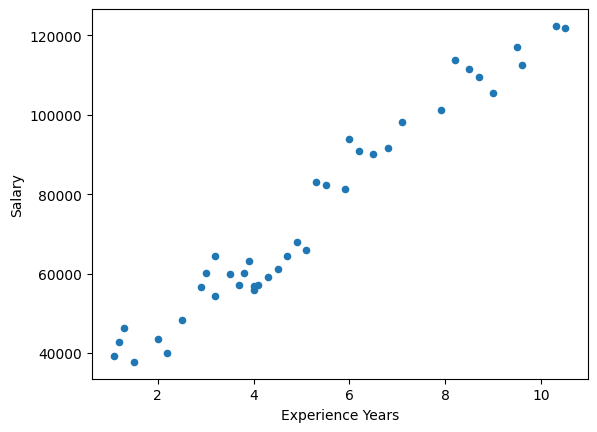

In [18]:
df.plot(x='Experience Years', y='Salary', kind='scatter')

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [19]:
print("The relationship between Experience Years and Salary is INCREASING.")
print("As the years of experience increase, the salary tends to increase as well.")
print("This indicates a positive correlation between the feature (Experience Years) and the target (Salary).")

The relationship between Experience Years and Salary is INCREASING.
As the years of experience increase, the salary tends to increase as well.
This indicates a positive correlation between the feature (Experience Years) and the target (Salary).


### Step 7. Initialize a regression model

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Step 9.a Train the model on the training set

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [24]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 9408.03127250658
Intercept: 26716.250176145535


### Step 9.c how much salary does a person get with 2 years of experience?

In [25]:
salary_2_years = model.predict([[2]])

print("Predicted salary for 2 years of experience:", salary_2_years[0])

Predicted salary for 2 years of experience: 45532.3127211587


c:\Users\96650\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [26]:
increase_6_months = model.coef_[0] * 0.5

print("Increase in salary for 6 months experience:", increase_6_months)

Increase in salary for 6 months experience: 4704.01563625329


### Step 9.e if one has zero experience, then how much is the estimated salary?ac

In [27]:
print("Estimated salary with 0 years of experience:", model.intercept_)

Estimated salary with 0 years of experience: 26716.250176145535


### Step 10. Evaluate the model on the test set

In [28]:
test_score = model.score(X_test, y_test)

print("Model R^2 score on test set:", test_score)

Model R^2 score on test set: 0.9068577573647874


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [29]:
sample_X = X_test.iloc[:3]
sample_y_true = y_test.iloc[:3]

sample_y_pred = model.predict(sample_X)

print("Sample input (Years of Experience):")
print(sample_X)

print("\nActual Salary:")
print(sample_y_true.values)

print("\nPredicted Salary:")
print(sample_y_pred)

Sample input (Years of Experience):
    Experience Years
19               4.5
16               4.0
15               4.0

Actual Salary:
[61111 56957 55794]

Predicted Salary:
[69052.39090243 64348.37526617 64348.37526617]


### Step 12. Plot the data and the regression line

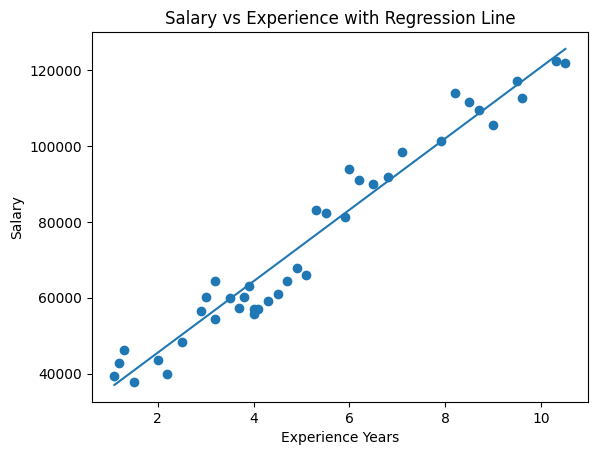

In [31]:
import matplotlib.pyplot as plt

plt.scatter(X, y)

X_line = X.sort_values(by=X.columns[0])
y_line = model.predict(X_line)

plt.plot(X_line, y_line)

plt.xlabel(X.columns[0])
plt.ylabel("Salary")

plt.title("Salary vs Experience with Regression Line")

plt.show()